Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_csv("../data/models/metrics.csv")
df

,model,val_f1,val_precision,val_recall,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
0,logistic_regression,0.234828,0.528148,0.250066,0.250066,0.331433,0.343903,0.409973,0.409973
1,random_forest,0.394884,0.452284,0.508785,0.508785,0.348561,0.349610,0.459328,0.459328
2,xgboost,0.359191,0.377681,0.510939,0.510939,0.329595,0.332395,0.471514,0.471514
3,LightGBM,0.463250,0.455699,0.532653,0.532653,0.337713,0.328044,0.444780,0.444780
4,catboost,0.517643,0.541657,0.506657,0.506657,0.337412,0.331330,0.441750,0.441750


Sort models by test F1 for consistent plotting

In [2]:
df_sorted = df.sort_values(by="test_f1", ascending=False)
df_sorted

,model,val_f1,val_precision,val_recall,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
1,random_forest,0.394884,0.452284,0.508785,0.508785,0.348561,0.349610,0.459328,0.459328
3,LightGBM,0.463250,0.455699,0.532653,0.532653,0.337713,0.328044,0.444780,0.444780
4,catboost,0.517643,0.541657,0.506657,0.506657,0.337412,0.331330,0.441750,0.441750
0,logistic_regression,0.234828,0.528148,0.250066,0.250066,0.331433,0.343903,0.409973,0.409973
2,xgboost,0.359191,0.377681,0.510939,0.510939,0.329595,0.332395,0.471514,0.471514


Bar Charts for Test Metrics

C:\Users\John Waugh\AppData\Local\Temp\ipykernel_19076\2070518401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right") # Rotate x-axis labels for readability
C:\Users\John Waugh\AppData\Local\Temp\ipykernel_19076\2070518401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right") # Rotate x-axis labels for readability
C:\Users\John Waugh\AppData\Local\Temp\ipykernel_19076\2070518401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right") # Rotate x-axis labels for readability
C:\Users\John Waugh\AppData\Local\Temp\ipykernel_19076\2070518401.py:10: UserWarni

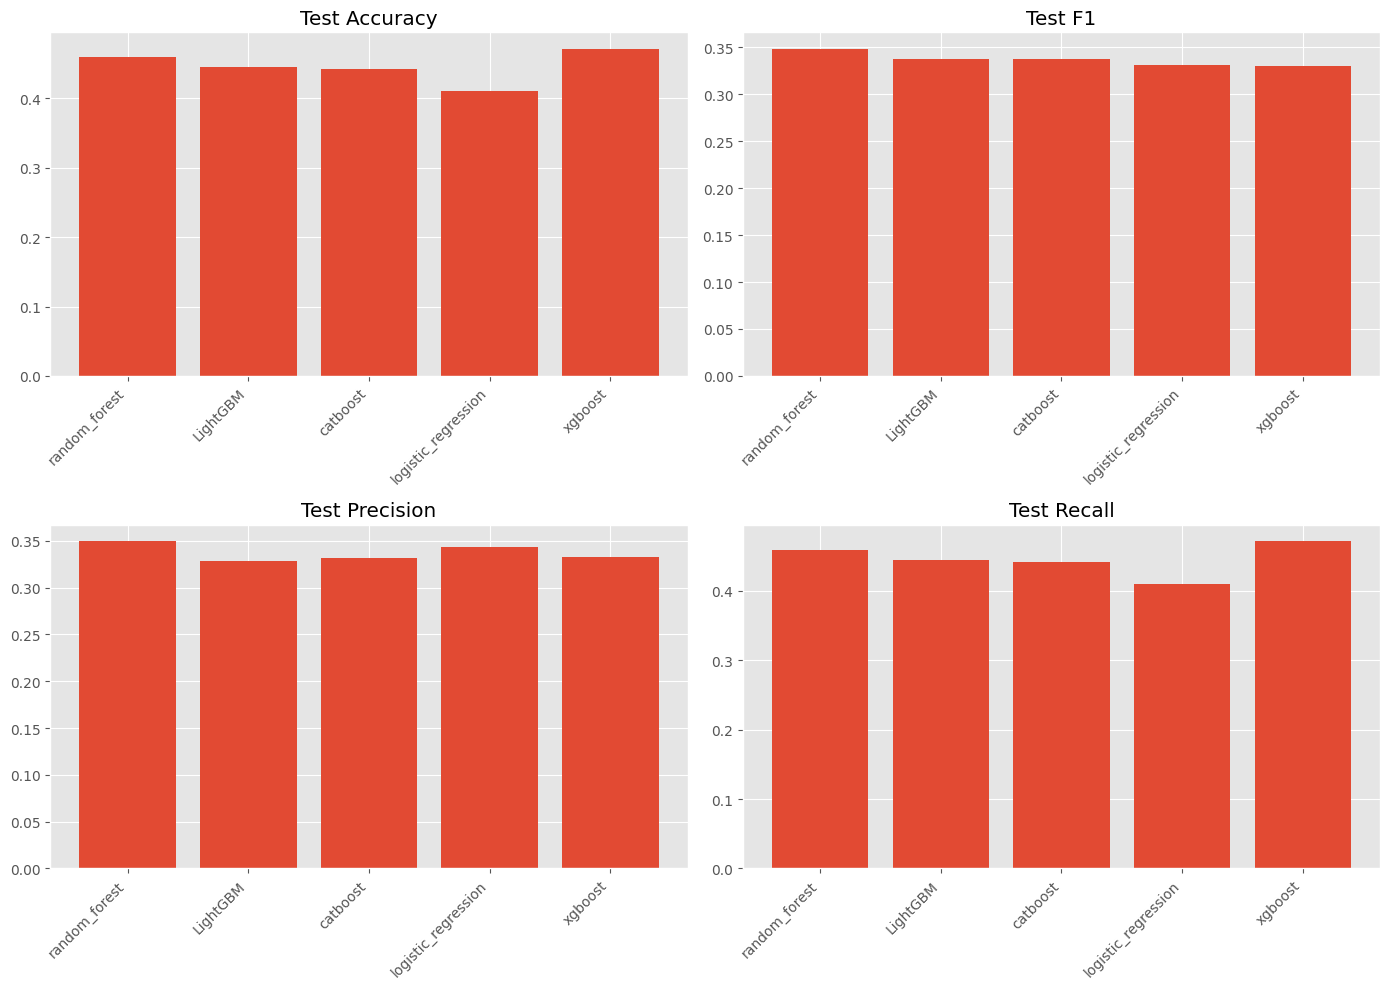

In [3]:
metrics = ["test_accuracy", "test_f1", "test_precision", "test_recall"] # Test metrics to visualize

fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Create 2x2 grid of subplots
axes = axes.ravel() # Flatten 2D array of axes to 1D for easy indexing

for i, metric in enumerate(metrics):
    ax = axes[i] # Select subplot
    ax.bar(df_sorted["model"], df_sorted[metric]) # Bar chart of metric values
    ax.set_title(f"{metric.replace('_', ' ').title()}") # Set title
    ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right") # Rotate x-axis labels for readability

plt.tight_layout() # Adjust layout to prevent overlap
plt.savefig("../figures/model_performance_metrics.png")
plt.show()

Validation vs Test Comparision

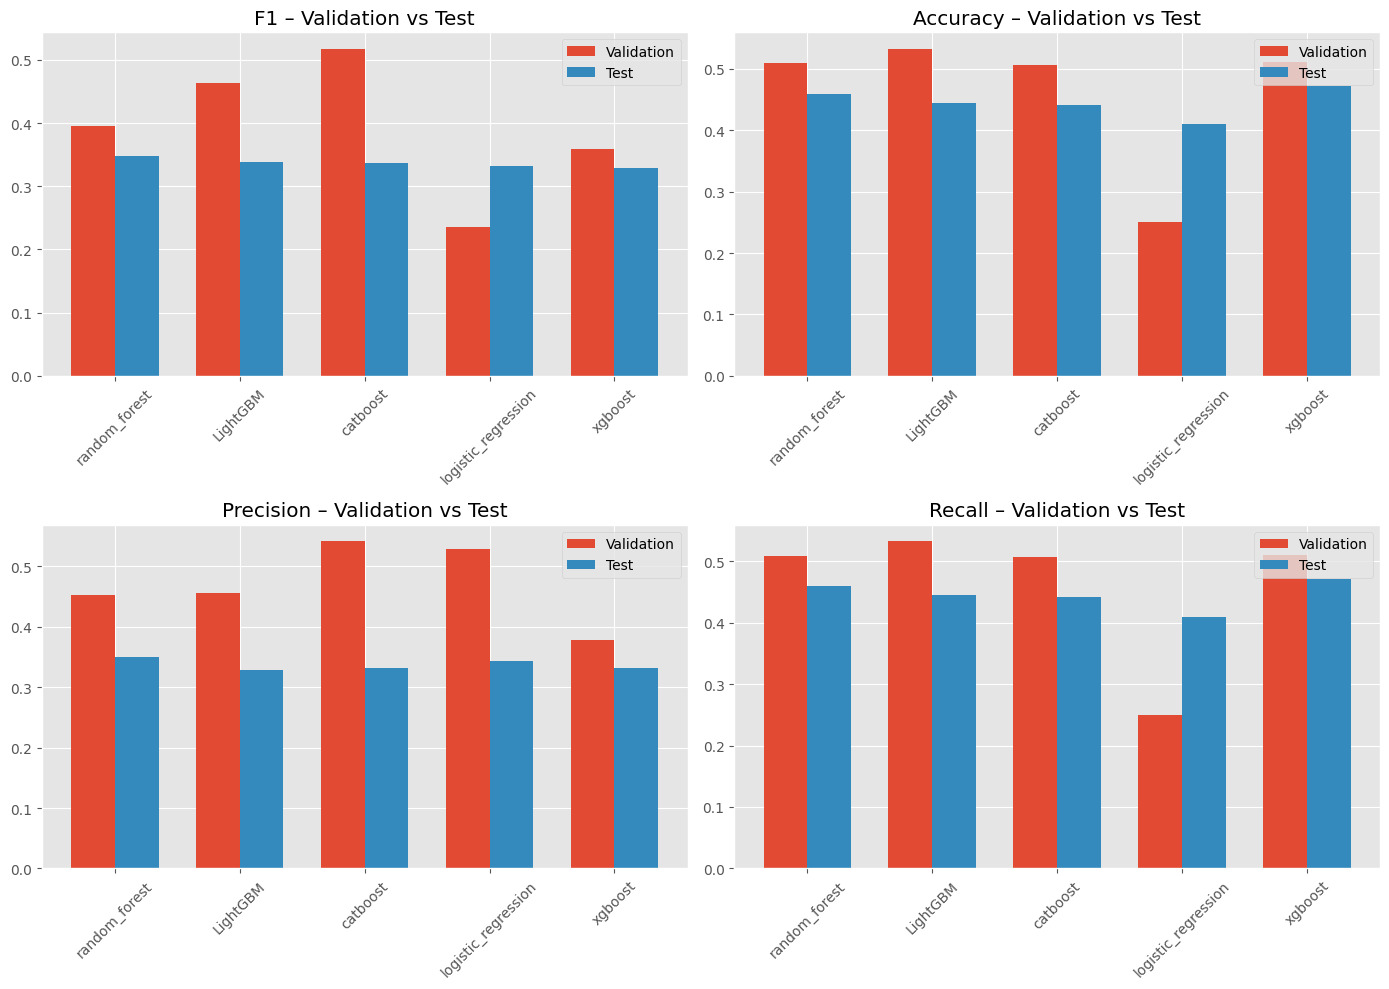

In [4]:
# Pairs of metric columns to compare
pairs = [
    ("val_f1", "test_f1"),
    ("val_accuracy", "test_accuracy"),
    ("val_precision", "test_precision"),
    ("val_recall", "test_recall")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

x = np.arange(len(df_sorted["model"])) # One bar per model
width = 0.35

for i, (v, t) in enumerate(pairs):
    ax = axes[i] 
    ax.bar(x - width/2, df_sorted[v], width, label="Validation") # Left bar (val)
    ax.bar(x + width/2, df_sorted[t], width, label="Test") # Right bar (test)
    ax.set_title(f"{v.replace('val_', '').title()} – Validation vs Test")
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted["model"], rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/val_vs_test_metrics.png")
plt.show()

Radar Plots

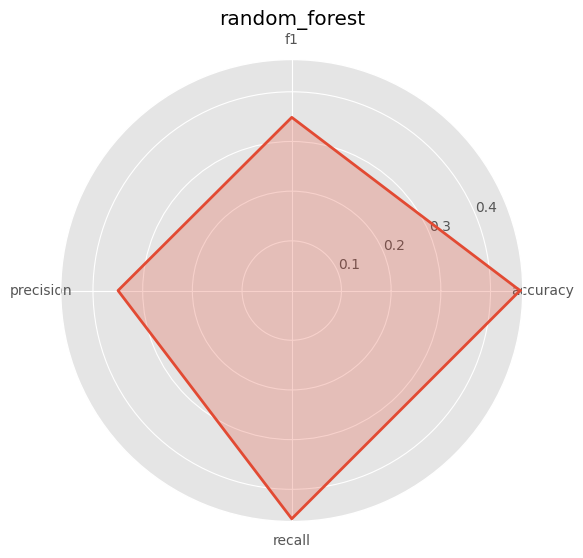

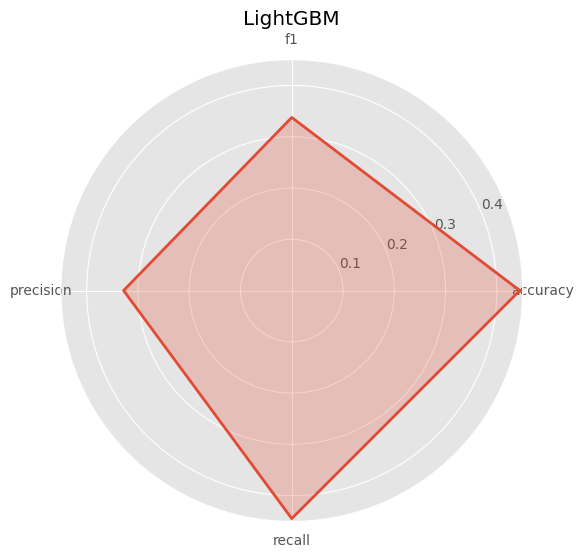

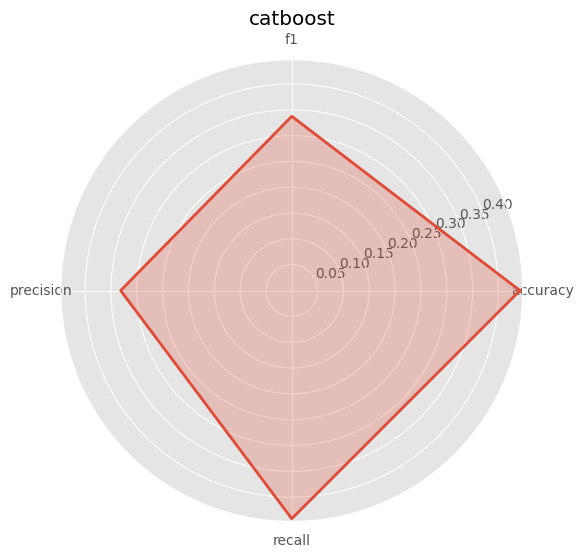

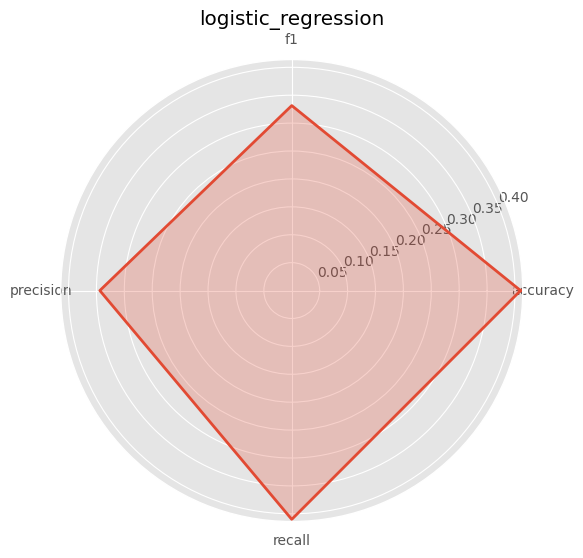

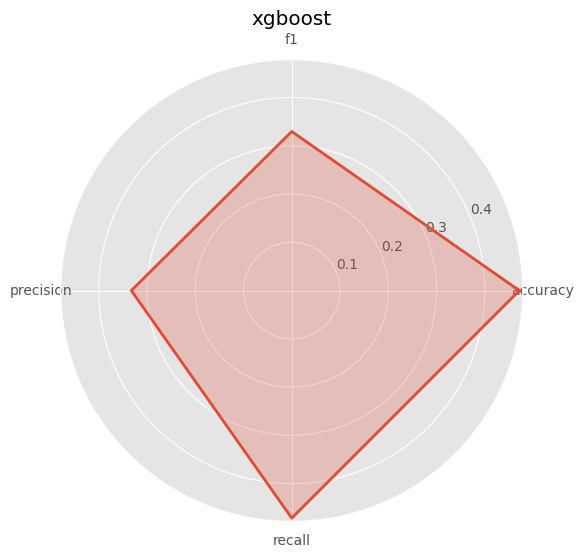

In [5]:
metrics = ["test_accuracy", "test_f1", "test_precision", "test_recall"]

def radar_plot(row):
    values = row[metrics].values # Get metric values for a model
    labels = metrics # Metric names
    
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False) # Evenly spaced angles for each axis
    values = np.concatenate([values, values[:1]]) # Repeat first value to close shape
    angles = np.concatenate([angles, angles[:1]]) # Repeat first angle to close shape

    fig = plt.figure(figsize=(6, 6)) 
    ax = plt.subplot(111, polar=True) # Polar coordinate axis
    ax.plot(angles, values, linewidth=2) # Draw radar line
    ax.fill(angles, values, alpha=0.25) # Fill area under line
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.replace('test_', '') for m in metrics])
    ax.set_title(row["model"])
    plt.savefig(f"../figures/radar_{row['model']}.png")
    plt.show()

# Generate radar plots for each model
for _, row in df_sorted.iterrows():
    radar_plot(row)

Ranking plot based on Test F1

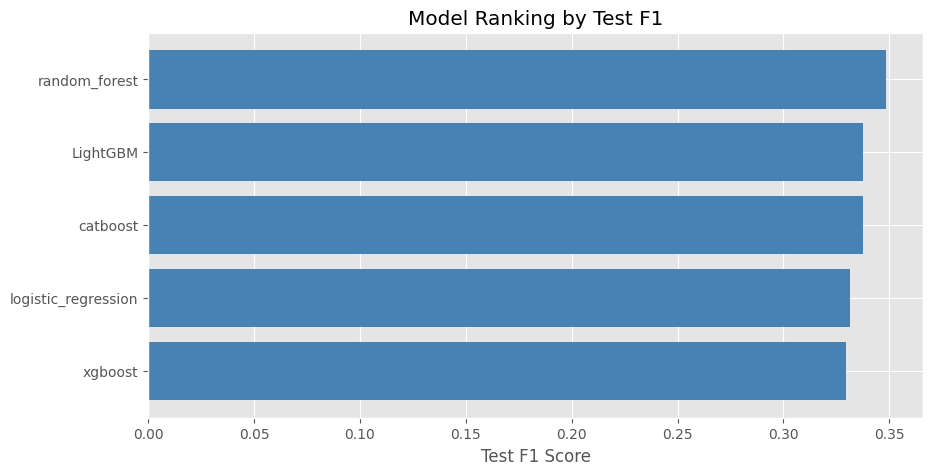

In [6]:
plt.figure(figsize=(10, 5))
plt.barh(df_sorted["model"], df_sorted["test_f1"], color="steelblue")
plt.xlabel("Test F1 Score")
plt.title("Model Ranking by Test F1")
plt.gca().invert_yaxis()
plt.savefig("../figures/model_ranking_test_f1.png")
plt.show()

Correlation Heatmap Between Metrics

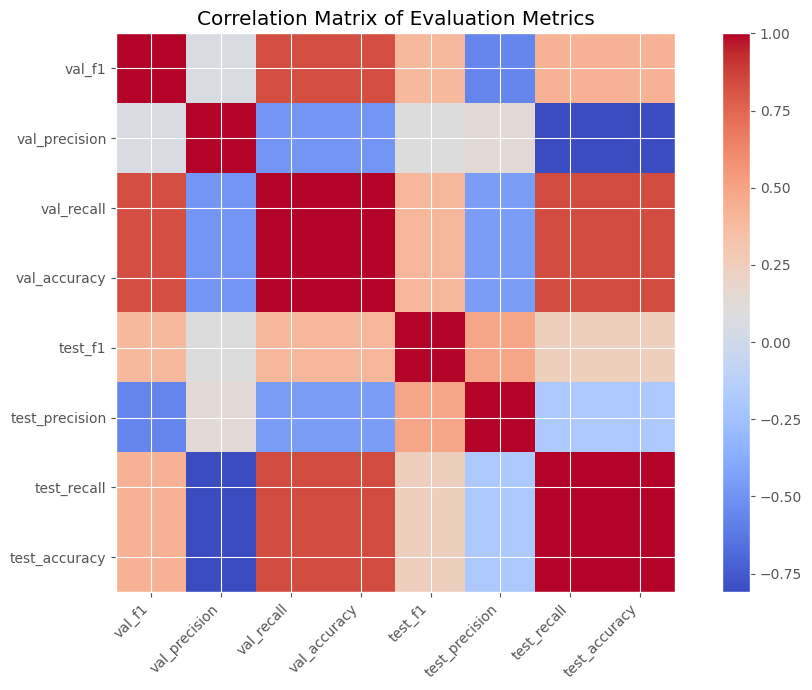

In [7]:
metric_cols = [c for c in df.columns if c not in ["model"]] # Keep only numeric metric columns
corr = df[metric_cols].corr() # Compute correlation matrix

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(metric_cols)), metric_cols, rotation=45, ha="right")
plt.yticks(range(len(metric_cols)), metric_cols)
plt.title("Correlation Matrix of Evaluation Metrics")
plt.tight_layout()
plt.savefig("../figures/metrics_correlation_matrix.png")
plt.show()

Table Summary

In [8]:
df_sorted.style.background_gradient(cmap="Blues")

,model,val_f1,val_precision,val_recall,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
1,random_forest,0.394884,0.452284,0.508785,0.508785,0.348561,0.349610,0.459328,0.459328
3,LightGBM,0.463250,0.455699,0.532653,0.532653,0.337713,0.328044,0.444780,0.444780
4,catboost,0.517643,0.541657,0.506657,0.506657,0.337412,0.331330,0.441750,0.441750
0,logistic_regression,0.234828,0.528148,0.250066,0.250066,0.331433,0.343903,0.409973,0.409973
2,xgboost,0.359191,0.377681,0.510939,0.510939,0.329595,0.332395,0.471514,0.471514
